# 文件: chart_68_1.py

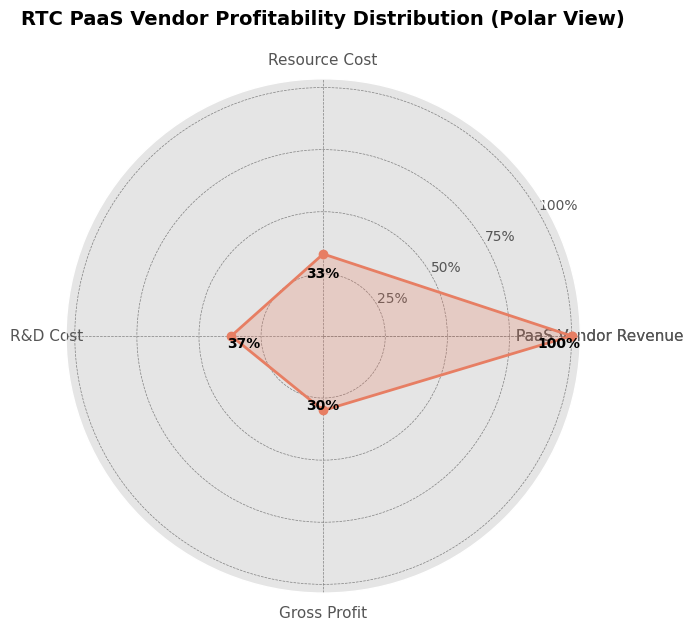

In [11]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Set the style and color palette
plt.style.use("ggplot")
sns.set_palette("Set2")

# Data
categories = ["PaaS Vendor Revenue", "Resource Cost", "R&D Cost", "Gross Profit"]
data = [100, 33, 37, 30]
colors = sns.color_palette("flare", len(data))  # Bright gradient color scheme

# Polar plot (a variant of radar chart) - only one dimension, can also be simulated with a pie chart
fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))

# Polar angles
angles = np.linspace(0, 2 * np.pi, len(data), endpoint=False).tolist()
# Close the shape
data += data[:1]
angles += angles[:1]

# Plotting
ax.fill(angles, data, color=colors[0], alpha=0.25)
ax.plot(angles, data, color=colors[0], linewidth=2, linestyle="-", marker='o')

# Add data labels
for angle, value, label in zip(angles[:-1], data[:-1], categories):
    ax.text(
        angle,
        value - 5,  # Offset outward a bit to prevent overlapping with the graph, adjustable
        f"{value}%",
        ha='center',
        va='top',
        fontsize=10,
        color='black',
        fontweight='bold'
    )

# Set category labels
categories += categories[:1]
ax.set_xticks(angles)
ax.set_xticklabels(categories, fontsize=11)

# Set the title
plt.title("RTC PaaS Vendor Profitability Distribution (Polar View)", fontsize=14, fontweight="bold", pad=20)

# Configure the axis range
ax.set_rlabel_position(30)
ax.set_yticks([25, 50, 75, 100])
ax.set_yticklabels(["25%", "50%", "75%", "100%"], fontsize=10)
ax.grid(color="gray", linestyle="--", linewidth=0.5)

plt.tight_layout()
plt.show()

# 文件: chart_68_2.py

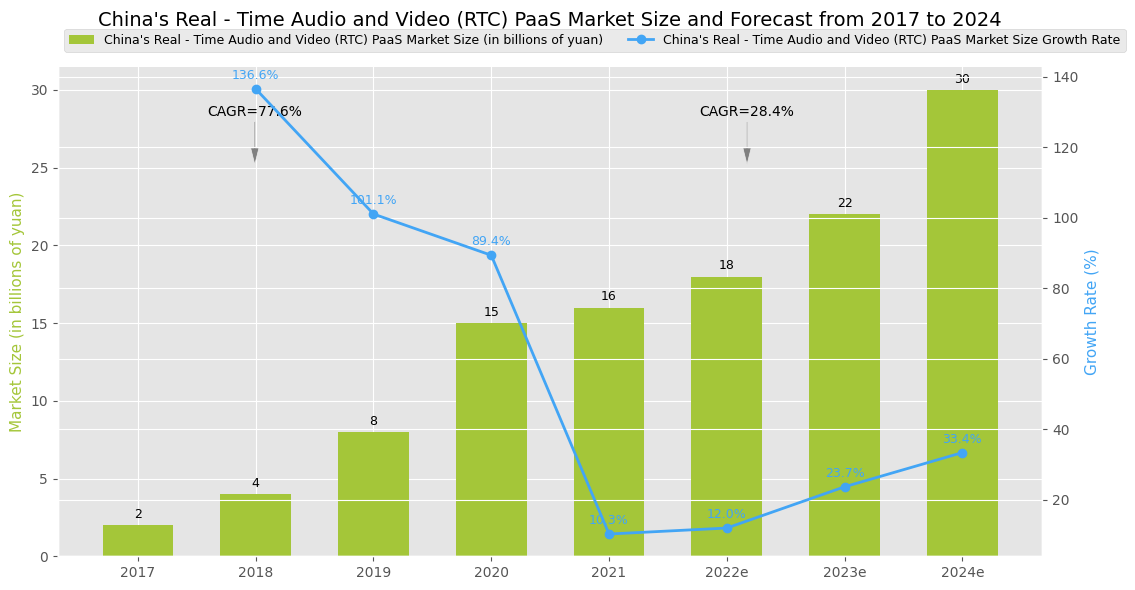

In [2]:
import matplotlib.pyplot as plt
import numpy as np

# Simulated data (consistent with the trend of the original graph)
years = ["2017", "2018", "2019", "2020", "2021", "2022e", "2023e", "2024e"]
market_size = np.array([2, 4, 8, 15, 16, 18, 22, 30])  # Market size (in billions of yuan)
growth_rate = np.array([136.6, 101.1, 89.4, 10.3, 12.0, 23.7, 33.4])  # Growth rate (%), note that the length is 1 less than years (no growth rate for 2017)

# Initialize a dual-axis canvas
fig, ax1 = plt.subplots(figsize=(12, 6))
ax2 = ax1.twinx()

# Draw a bar chart (market size)
x = np.arange(len(years))
bar_width = 0.6
rects = ax1.bar(x, market_size, width=bar_width, label="China's Real - Time Audio and Video (RTC) PaaS Market Size (in billions of yuan)", color="#A4C639")

# Draw a line chart (growth rate)
line, = ax2.plot(x[1:], growth_rate, marker="o", color="#42A5F5", label="China's Real - Time Audio and Video (RTC) PaaS Market Size Growth Rate", linewidth=2)

# Add market size annotations (on top of the bar chart)
for rect in rects:
    height = rect.get_height()
    ax1.annotate(f'{height}', 
                 xy=(rect.get_x() + rect.get_width()/2, height),
                 xytext=(0, 3),
                 textcoords="offset points",
                 ha='center', va='bottom', fontsize=9)

# Add growth rate annotations (above the points of the line chart)
for i, rate in enumerate(growth_rate):
    ax2.annotate(f'{rate}%', 
                 xy=(x[i+1], rate),  # x starts from 2018 (index 1)
                 xytext=(0, 5),
                 textcoords="offset points",
                 ha='center', va='bottom', fontsize=9, color="#42A5F5")

# Add CAGR annotations (manually simulate arrows and text)
ax1.annotate(
    "CAGR=77.6%", 
    xy=(0.2, 0.8), xycoords="axes fraction",
    xytext=(0.2, 0.9), textcoords="axes fraction",
    arrowprops=dict(facecolor='gray', width=1, headwidth=6),
    fontsize=10, ha='center'
)
ax1.annotate(
    "CAGR=28.4%", 
    xy=(0.7, 0.8), xycoords="axes fraction",
    xytext=(0.7, 0.9), textcoords="axes fraction",
    arrowprops=dict(facecolor='gray', width=1, headwidth=6),
    fontsize=10, ha='center'
)

# Axes and legend configuration
ax1.set_xticks(x)
ax1.set_xticklabels(years, fontsize=10)
ax1.set_ylabel("Market Size (in billions of yuan)", fontsize=11, color="#A4C639")
ax2.set_ylabel("Growth Rate (%)", fontsize=11, color="#42A5F5")

# Combine legends (solve the problem of overlapping legends on dual - axes)
handles, labels = ax1.get_legend_handles_labels()
handles.append(line)
labels.append(line.get_label())
ax1.legend(handles, labels, loc="upper left", bbox_to_anchor=(0, 1.09), ncol=2, fontsize=9)

# Title and beautification
plt.title("China's Real - Time Audio and Video (RTC) PaaS Market Size and Forecast from 2017 to 2024", fontsize=14, pad=30)
ax1.spines['top'].set_visible(False)
ax2.spines['top'].set_visible(False)
plt.tight_layout()

# Display the chart
plt.show()

# 文件: chart_68_3.py

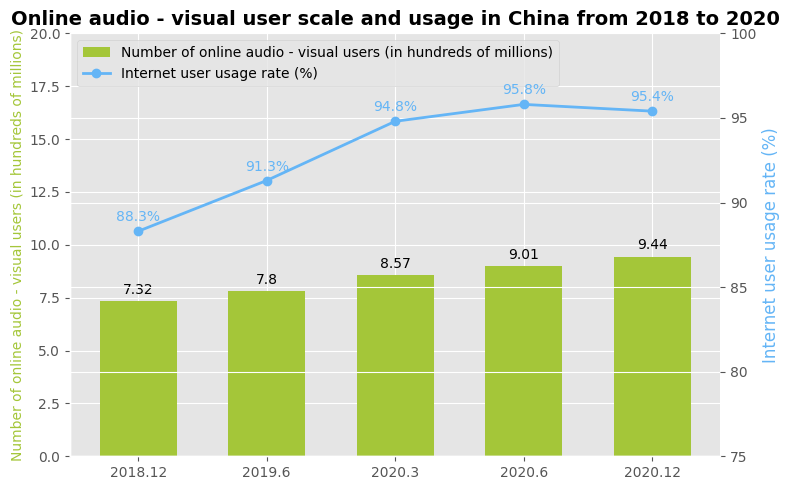

In [16]:
import matplotlib.pyplot as plt
import numpy as np

# Time nodes
years = ["2018.12", "2019.6", "2020.3", "2020.6", "2020.12"]
# Number of online audio - visual users (in hundreds of millions)
user_scale = [7.32, 7.8, 8.57, 9.01, 9.44]
# Internet user usage rate (%)
usage_rate = [88.3, 91.3, 94.8, 95.8, 95.4]

# Create a canvas and sub - plots with a dual y - axis
fig, ax1 = plt.subplots(figsize=(8, 5))
ax2 = ax1.twinx()

ax1.set_ylim(0, 20)  # Y - axis for the number of users (in hundreds of millions)
ax2.set_ylim(75, 100)  # Y - axis for the usage rate (%)

# Draw a bar chart of the number of online audio - visual users
x = np.arange(len(years))
bar_width = 0.6
bars = ax1.bar(x, user_scale, width=bar_width, color="#A4C639", label="Number of online audio - visual users (in hundreds of millions)")

# Draw a line chart of the internet user usage rate
line, = ax2.plot(x, usage_rate, marker='o', color="#64B5F6", label="Internet user usage rate (%)", linewidth=2)

# Add data labels for the number of users
for bar in bars:
    height = bar.get_height()
    ax1.annotate(f'{height}',
                 xy=(bar.get_x() + bar.get_width() / 2, height),
                 xytext=(0, 3),  # Adjust the label position
                 textcoords="offset points",
                 ha='center', va='bottom')

# Add data labels for the usage rate
for x_val, y_val in zip(x, usage_rate):
    ax2.annotate(f'{y_val}%',
                 xy=(x_val, y_val),
                 xytext=(0, 5),  # Adjust the label position
                 textcoords="offset points",
                 ha='center', va='bottom',
                 color="#64B5F6")

# Set the x - axis ticks and labels
ax1.set_xticks(x)
ax1.set_xticklabels(years)
# Set the y - axis labels
ax1.set_ylabel("Number of online audio - visual users (in hundreds of millions)", color="#A4C639", fontsize=10)
ax2.set_ylabel("Internet user usage rate (%)", color="#64B5F6")
# Set the title
ax1.set_title("Online audio - visual user scale and usage in China from 2018 to 2020", fontsize=14, fontweight="bold")

# Combine legends
handles, labels = ax1.get_legend_handles_labels()
handles.append(line)
labels.append(line.get_label())
ax1.legend(handles, labels, loc='upper left')

# Beautify the chart by hiding the top and right borders (for ax1 and ax2)
for spine in ["top", "right"]:
    ax1.spines[spine].set_visible(False)
    ax2.spines[spine].set_visible(False)

plt.tight_layout()  # Automatically adjust the layout
plt.show()